In [1]:
# some libraries we will need
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.constants as ac
#import cmasher as cm
import quantities

import sfe_prescriptions as sfes

import fb_models
import wind_solutions

from scipy.integrate import solve_ivp

from scipy.optimize import brentq

In [2]:
Lw = 1e38*u.erg/u.s
Mdotw = 1e-4*u.Msun/u.yr
Vwind = np.sqrt(2*Lw/Mdotw).to(u.km/u.s)
pdotw = (Mdotw*Vwind).to(u.Msun*u.km/u.s/u.Myr)

nHbar = 100./(u.cm**3)
muH = 1.4
rho = ac.m_p*muH*nHbar

In [3]:
ad_bub = fb_models.AdiabaticWind(Lwind=Lw,rho0=rho,rfb=1*u.AU)

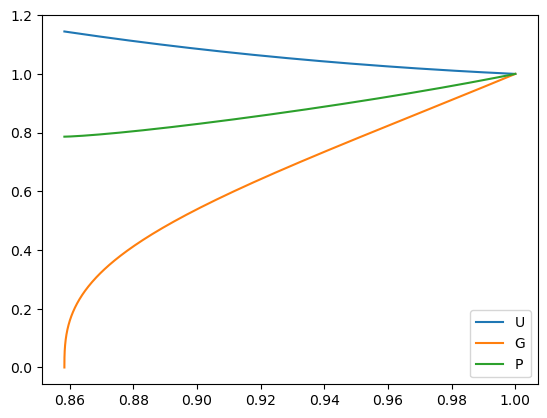

In [4]:
plt.plot(ad_bub.ad_shell_sol.t, ad_bub.ad_shell_sol.y[0]/ad_bub.ad_shell_sol.y[0][0],label="U")
plt.plot(ad_bub.ad_shell_sol.t, ad_bub.ad_shell_sol.y[1]/ad_bub.ad_shell_sol.y[1][0],label="G")
plt.plot(ad_bub.ad_shell_sol.t, ad_bub.ad_shell_sol.y[2]/ad_bub.ad_shell_sol.y[2][0],label="P")
plt.legend()

In [28]:
rlin = np.logspace(-1,2,10000)*u.pc
tlin = np.logspace(-2,0,4)*u.Myr

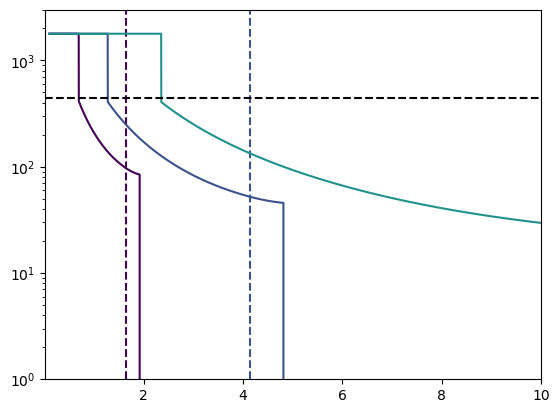

In [30]:
#plt.plot(rlin, (free_wind.rho(rlin)/(ac.m_p)).to(u.cm**-3))
for (i,t) in enumerate(tlin[:3]):
    plt.plot(rlin, ad_bub.velocity_profile(rlin,t),c=plt.cm.viridis((1.*i)/len(tlin.value)))
    #plt.axvline(x=ad_bub.radius(t).value,c=plt.cm.viridis((1.*i)/len(tlin.value)),ls='--')
    plt.axvline(x=ad_bub.xic*ad_bub.radius(t).value,c=plt.cm.viridis((1.*i)/len(tlin.value)),ls='--')
#plt.axhline(y=free_wind.vinf.value)
plt.axhline(y=Vwind.value/4,c='k',ls='--')
plt.ylim(1,3e3)
plt.xlim(0.01,10)
plt.yscale('log')
#plt.xscale('log')

In [11]:
ad_bub.ad_shell_sol

  message: Required step size is less than spacing between numbers.
  success: False
   status: -1
        t: [ 1.000e+00  9.988e-01 ...  8.584e-01  8.584e-01]
        y: [[ 7.500e-01  7.504e-01 ...  8.584e-01  8.584e-01]
            [ 4.000e+00  3.979e+00 ...  1.257e-04  1.251e-04]
            [ 7.500e-01  7.481e-01 ...  5.897e-01  5.897e-01]]
      sol: <scipy.integrate._ivp.common.OdeSolution object at 0x1253b6cf0>
 t_events: [array([], dtype=float64)]
 y_events: [array([], dtype=float64)]
     nfev: 5462
     njev: 0
      nlu: 0

In [75]:
Nres = 512
Lx = 2*10.24*100*u.pc
dx = Lx/Nres

<Quantity 4. pc>

In [79]:
Lx = ((dx**3)*1.7688647437345838e-19*u.erg/(u.cm**3*u.s)).to(u.erg/u.s)

In [80]:
Lx

<Quantity 3.32603056e+38 erg / s>

In [26]:
quantities.Twshock(mdot, rhobar, vwind)

<Quantity 1.94988107e-05 Myr>

In [27]:
quantities.Tcool(rhobar/ac.m_p, Lw)

<Quantity 0.00068862 Myr>

In [31]:

Rcool = weaver.radius(quantities.Tcool(rhobar/ac.m_p, Lw))
dx_hr = 10*u.pc/64
print(Rcool)
print(weaver.radius(0.25*u.Myr))

0.332231428247097 pc
11.413492558561208 pc


In [32]:
(1*u.Lsun).to(u.erg/u.s)

<Quantity 3.828e+33 erg / s>

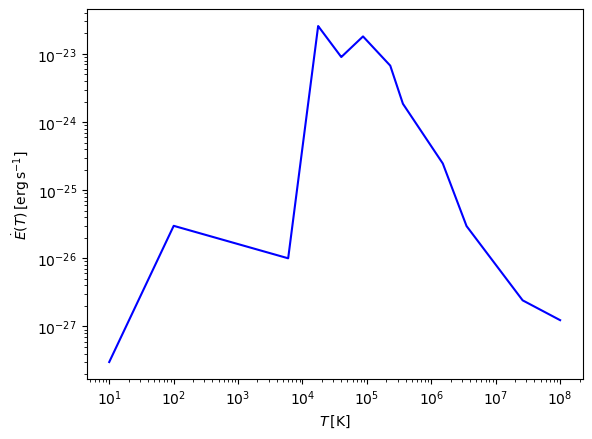

In [14]:
Tlin = np.logspace(1,8,10000)

n = 100
# pressure in K cm^-3
P = 3000
plt.plot(Tlin, [Lambda(T)*(P/T) for T in Tlin], 'b', label=r"$n\Lambda(T)$")
#plt.plot(Tlin, [Gamma(T) for T in Tlin], 'r', label=r"$\Gamma(T)$")
plt.xlabel(r"$T \, [{\rm K}]$")
plt.ylabel(r"$\dot{E}(T) \, [{\rm erg \, s^{-1}}]$")
#plt.legend()
plt.yscale("log")
plt.xscale("log")

In [118]:
Mcl = 1e5*u.Msun
nHlin = np.logspace(1, 6, 100)*u.cm**(-3)
(esc_res_pi,esc_res_weaver,esc_res_md,esc_res_dr,Mescs) = ([],[],[],[],[])
ci = 10*u.km/u.s
eps_st = 0.5
Mst = eps_st*Mcl
# metallicity relative to solar 
Zp = 0.01
# absorption fraciton by hydrogen
fH = 1.0
# mometnum enhancement factor of wind
ap = 10.0
# infrared optical depth
tau_ir = 1.0

# feedback parameters
Xi = fH*4.106e46/u.s/u.Msun
Psiw = 9.58*u.km/u.s/u.Myr
Lw_Mst = 1e34*(Zp**0.8)*u.erg/u.s/u.Msun
for nHbar in nHlin:
    muH = 1.4
    rhobar = 1.4*nHbar*ac.m_p
    Rcl = quantities.Rcl(Mcl, nHbar)
    Q0 = Xi*Mst
    Lw = Lw_Mst*Mst
    pdotw = Psiw*(Zp**0.61)*Mst
    pdotdr = 2*(1+tau_ir)*Psiw*Mst

    tff = quantities.Tff(rhobar)
    v_esc = ((6*ac.G*Mcl/(5*Rcl))**0.5).to("km/s")

    spitz_bubble = fb_models.Spitzer(rhobar, Q0)
    weaver_bubble = fb_models.Weaver(rhobar,Lw)
    md_wind = fb_models.MomentumDriven(rhobar,ap*pdotw)
    md_dr = fb_models.MomentumDriven(rhobar,pdotdr)

    Mescs.append((v_esc/ci).to(" "))
    esc_res_pi.append((spitz_bubble.momentum(tff)/(Mcl*v_esc)).to(" "))
    esc_res_weaver.append((weaver_bubble.momentum(tff)/(Mcl*v_esc)).to(" "))
    esc_res_md.append((md_wind.momentum(tff)/(Mcl*v_esc)).to(" "))
    esc_res_dr.append((md_dr.momentum(tff)/(Mcl*v_esc)).to(" "))
(esc_res_pi,esc_res_weaver,Mescs) = (np.array(esc_res_pi),np.array(esc_res_weaver),np.array(Mescs))
(esc_res_md,esc_res_dr) = (np.array(esc_res_md),np.array(esc_res_dr))

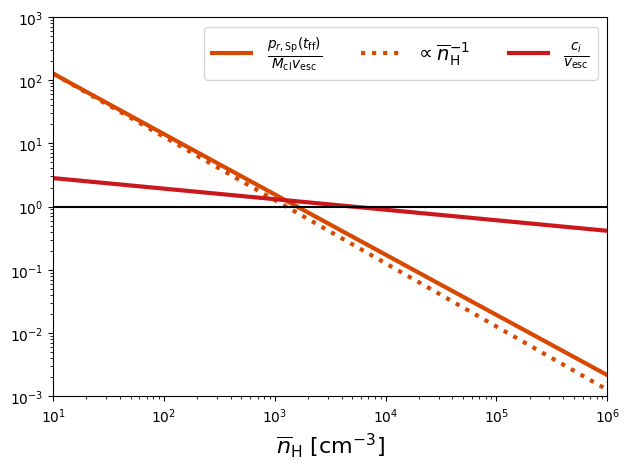

In [76]:
plt.plot(nHlin,esc_res_pi,c=plt.cm.Oranges(0.75),label=r"$\frac{p_{r,{\rm Sp}} (t_{\rm ff})}{M_{\rm cl} v_{\rm esc}}$",lw=3)
plt.plot(nHlin,esc_res_pi[0]*(nHlin/nHlin[0])**-1,':',c=plt.cm.Oranges(0.75), label=r"$\propto \overline{n}_{\rm H}^{-1}$",lw=3)
plt.plot(nHlin,1./Mescs,c=plt.cm.Reds(0.75),label=r"$\frac{c_i}{v_{\rm esc}}$",lw=3)

#plt.plot(nHlin,esc_res_weaver,c=plt.cm.Greens(0.75),label=r"$\frac{p_{r, {\rm W}}(t_{\rm ff})}{M_{\rm cl}v_{\rm esc}}$",lw=3)
#plt.plot(nHlin,esc_res_md,c=plt.cm.Purples(0.75),label=r"$\frac{p_{r, {\rm MD}}(t_{\rm ff})}{M_{\rm cl}v_{\rm esc}}$",lw=3)

plt.xlabel(r"$\overline{n}_{\rm H}$ [cm$^{-3}$]",fontdict={"size":16})
#plt.ylabel(r"$\frac{p_r (t_{\rm ff})}{M_{\rm cl}v_{\rm esc}}$",fontdict={"size":16})
plt.axhline(y=1,c="k")

plt.legend(fontsize = 14, ncol=3)
plt.yscale("log")
plt.xscale("log")
plt.xlim(nHlin[0].value,nHlin[-1].value)
plt.ylim(1e-3,1e3)
plt.tight_layout()

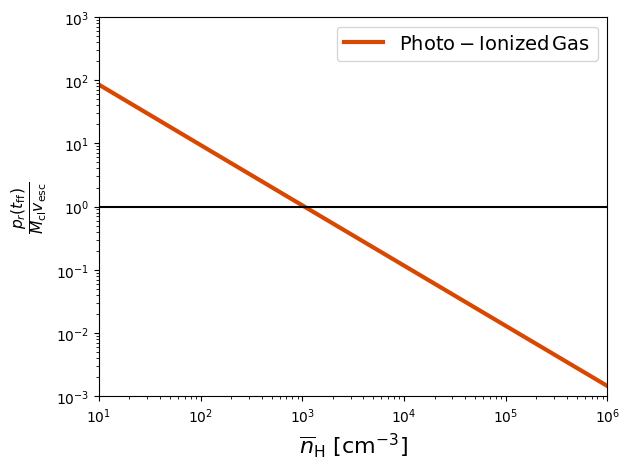

In [81]:
plt.plot(nHlin,esc_res_pi,c=plt.cm.Oranges(0.75),label=r"${\rm Photo-Ionized}\, {\rm Gas}$",lw=3)
#plt.plot(nHlin,esc_res_weaver,c=plt.cm.Greens(0.75),label=r"$\frac{p_{r, {\rm W}}(t_{\rm ff})}{M_{\rm cl}v_{\rm esc}}$",lw=3)
#plt.plot(nHlin,esc_res_md,c=plt.cm.Purples(0.75),label=r"$\frac{p_{r, {\rm MD}}(t_{\rm ff})}{M_{\rm cl}v_{\rm esc}}$",lw=3)
#plt.plot(nHlin,esc_res_pi[0]*(nHlin/nHlin[0])**-1,':',c=plt.cm.Blues(0.75), label=r"$\propto \overline{n}_{\rm H}^{-1}$",lw=3)
#plt.plot(nHlin,1./Mescs,c=plt.cm.Reds(0.75),label=r"$\frac{c_i}{v_{\rm esc}}$",lw=3)

plt.xlabel(r"$\overline{n}_{\rm H}$ [cm$^{-3}$]",fontdict={"size":16})
plt.ylabel(r"$\frac{p_r (t_{\rm ff})}{M_{\rm cl}v_{\rm esc}}$",fontdict={"size":16})
plt.axhline(y=1,c="k")

plt.legend(fontsize = 14, ncol=3)
plt.yscale("log")
plt.xscale("log")
plt.xlim(nHlin[0].value,nHlin[-1].value)
plt.ylim(1e-3,1e3)
plt.tight_layout()

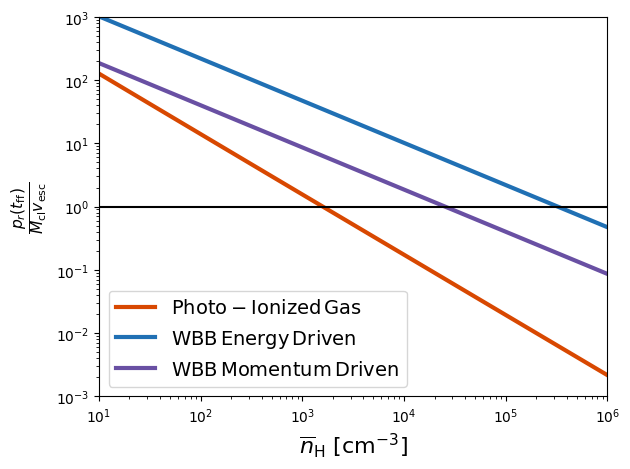

In [93]:
plt.plot(nHlin,esc_res_pi,c=plt.cm.Oranges(0.75),label=r"${\rm Photo-Ionized}\, {\rm Gas}$",lw=3)
plt.plot(nHlin,esc_res_weaver,c=plt.cm.Blues(0.75),label=r"${\rm WBB}\, {\rm Energy}\, {\rm Driven}$",lw=3)
plt.plot(nHlin,esc_res_md,c=plt.cm.Purples(0.75),label=r"${\rm WBB}\, {\rm Momentum}\, {\rm Driven}$",lw=3)
#plt.plot(nHlin,esc_res_pi[0]*(nHlin/nHlin[0])**-1,':',c=plt.cm.Blues(0.75), label=r"$\propto \overline{n}_{\rm H}^{-1}$",lw=3)
#plt.plot(nHlin,1./Mescs,c=plt.cm.Reds(0.75),label=r"$\frac{c_i}{v_{\rm esc}}$",lw=3)

plt.xlabel(r"$\overline{n}_{\rm H}$ [cm$^{-3}$]",fontdict={"size":16})
plt.ylabel(r"$\frac{p_r (t_{\rm ff})}{M_{\rm cl}v_{\rm esc}}$",fontdict={"size":16})
plt.axhline(y=1,c="k")

plt.legend(fontsize = 14)
plt.yscale("log")
plt.xscale("log")
plt.xlim(nHlin[0].value,nHlin[-1].value)
plt.ylim(1e-3,1e3)
plt.tight_layout()

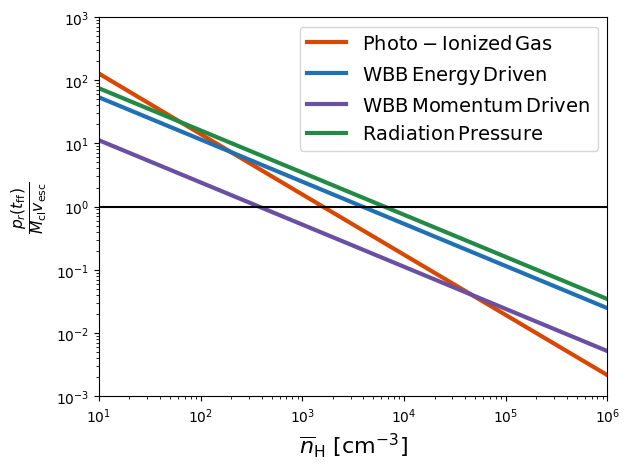

In [119]:
plt.plot(nHlin,esc_res_pi,c=plt.cm.Oranges(0.75),label=r"${\rm Photo-Ionized}\, {\rm Gas}$",lw=3)
plt.plot(nHlin,esc_res_weaver,c=plt.cm.Blues(0.75),label=r"${\rm WBB}\, {\rm Energy}\, {\rm Driven}$",lw=3)
plt.plot(nHlin,esc_res_md,c=plt.cm.Purples(0.75),label=r"${\rm WBB}\, {\rm Momentum}\, {\rm Driven}$",lw=3)
plt.plot(nHlin,esc_res_dr,c=plt.cm.Greens(0.75),label=r"${\rm Radiation}\, {\rm Pressure}$",lw=3)
#plt.plot(nHlin,esc_res_dr,c=plt.cm.viridis(0.75),label=r"${\rm Ly}\alpha$",lw=3)
#plt.plot(nHlin,esc_res_pi[0]*(nHlin/nHlin[0])**-1,':',c=plt.cm.Blues(0.75), label=r"$\propto \overline{n}_{\rm H}^{-1}$",lw=3)
#plt.plot(nHlin,1./Mescs,c=plt.cm.Reds(0.75),label=r"$\frac{c_i}{v_{\rm esc}}$",lw=3)

plt.xlabel(r"$\overline{n}_{\rm H}$ [cm$^{-3}$]",fontdict={"size":16})
plt.ylabel(r"$\frac{p_r (t_{\rm ff})}{M_{\rm cl}v_{\rm esc}}$",fontdict={"size":16})
plt.axhline(y=1,c="k")

plt.legend(fontsize = 14)
plt.yscale("log")
plt.xscale("log")
plt.xlim(nHlin[0].value,nHlin[-1].value)
plt.ylim(1e-3,1e3)
plt.tight_layout()

In [23]:
(((1e6*u.Msun)/(4*np.pi*(1*u.pc**3)/3))/(ac.m_p)).to("cm**-3")

<Quantity 9659794.34428722 1 / cm3>

In [25]:
quantities.Tff(1.4e7*ac.m_p*u.cm**-3).to("yr")

<Quantity 13755.95781518 yr>

In [125]:
R = quantities.Rcl(1e6*u.Msun,1e2*(u.cm**-3)).to("pc")

S = 1e6*u.Msun/(np.pi*R**2)

In [126]:
S

<Quantity 189.2155818 solMass / pc2>

In [131]:
P0 = 5e-6*u.dyne/u.cm**2
(P0/ac.k_B).to("K cm^-3")

<Quantity 3.62148526e+10 K / cm3>

In [136]:
pdot = 1e2*u.Msun*Psiw
rw = 0.001*u.pc
Pw = pdot/(4*np.pi*rw**2)
(Pw/ac.k_B).to("K cm^-3")


<Quantity 3.65403931e+11 K / cm3>

In [4]:
## Equations from Koo & McKee 1992b that I should specify at some point
def lambda_c(gamma,krho):
    eta = 3/(5-krho)
    t1 = gamma**3 + 12*gamma**2 + 8*gamma + 1
    t2 = -0.5*(gamma+1)*(3*gamma + 1)*krho
    t3 = (gamma+1)*(4*gamma + 1)/eta
    t4 = 2*gamma**3 + 12*gamma**2 + 7*gamma + 1
    return (t1+t2+t3)/(t4+t1+t3)

def Grad_xi(gsa,gsw,krho,etain=1):
    eta = 3/(5-krho)
    lc = lambda_c(gsa,krho)
    t1 = 9*(gsw - 1)*(gsa + 1)*etain
    t2a = 8*np.pi*eta
    t2b = 3*(gsw - 1)*eta + etain
    t2c = (4-krho)*eta - 1
    t2 = t2a*t2b*t2c*(lc**3)
    return t1/t2

C1 = 5.97e-35*u.g*(u.cm**-6)*(u.s**4)
muH_mH = 1.4*ac.m_p
nH = 100*u.cm**-3
rhobar = muH_mH*nH
Gx = 0.9
Lwind = 1e38*u.erg/u.s
tsf = ((27*C1/(125*rhobar))**(5./11))*((Gx*Lwind/rhobar)**(3./11))
tsf.to(u.yr)

ab = 3.11e-13*(u.cm**3)/u.s
C1 = 5.97e-35*u.g*(u.cm**-6)*(u.s**4)
qo = 1e50/u.s
lw = 1e38*u.erg/u.s
muH_mH = ac.m_p*1.4
mmc = muH_mH*(10*u.km/u.s)
rhobar = muH_mH*100/(u.cm**3)

t1 = (25*(mmc**2)*qo/(12*np.pi*ab))**(11./3)
t2 = ((lw*0.90)**(-14./3))
t3 = (125/(27*C1))**(5./3)
nHt = t1*t2*t3/muH_mH
print(np.log10((nHt.to(u.cm**-3)).value))
print(nHt.to(u.cm**-3))
tsf = ((27*C1/(125*rhobar))**(5./11))*(0.90*lw/rhobar)**(3./11)

3.908929519431811
8108.29459685234 1 / cm3


In [ ]:
nbar = 86.25/(u.cm**3)
rho0 = 1.4*aconsts.m_p*nbar
Q0 = 4.106e46*5e3/u.s
Mdotw = 2.965e-3*5e3*u.Msun/u.Myr
Vwind = 3230*u.km/u.s
Lwind = (0.5*Mdotw*Vwind**2).to(u.erg/u.s)

aps = np.linspace(1,8,40)
t = np.logspace(-5,0,1000)*u.Myr
outs = []
for alphap in aps:
    pdotw = alphap*Vwind*Mdotw
    jfbm = fb_models.JointBubbleUncoupled(rho0, Q0, pdotw)
    Rw = jfbm.wind_radius(t)
    Ri = jfbm.radius(t)
    pr = jfbm.momentum(t)
    out = np.array([t.value,Rw.value,Ri.value,pr.value]).T
    outs.append(out)

np.save("../joint_evolution_code/data/aps.npy",aps)     
np.save("../joint_evolution_code/data/jbfm.npy",outs)